# BNPL A2: ABS Census Data Pre-Processing

Uses ABS 2021 Census data (SA2 level) to analyse features relevant to a BNPL ranking system, and produce tables to be joined to customer, merchant and transaction data. Customer data is on postcode so there is a crosswalk so census attributes can be merged with customer data.

Creates a curated sa2_postcode_level dataframe for the merge

# Spark Session 

In [1]:
from pyspark.sql import SparkSession, functions as F
import sys

sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/11 14:35:40 WARN Utils: Your hostname, tray, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/09/11 14:35:40 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/11 14:35:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/11 14:35:43 WARN Utils: Service 'SparkUI' could not bind on

## Libraries

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

# Schema 

In [3]:
#helper as everything should be float except for the SA2_CODE_2021 column
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

def census_schema(path, key="SA2_CODE_2021"):
    # SA2 code stays a string; every other column is a double
    cols = spark.read.csv(str(path), header=True).columns
    return StructType([StructField(c, StringType() if c == key else DoubleType(), True)
                       for c in cols])

## Load Data 

In [4]:
# unzip data files

with zipfile.ZipFile("../data/2021_GCP_AUS_for_AUS_short-header.zip", "r") as zip_ref:
    zip_ref.extractall("../data/landing/external/")

In [5]:
import os

print(os.getcwd())
print(os.listdir('.'))

print(os.path.exists('../data/landing/2021Census_G02_AUST_SA2.csv'))
print(os.path.exists('data/landing/2021Census_G02_AUST_SA2.csv'))


/home/sarah/project-2-group-buy-now-pay-later-industry-project-21/notebooks
['.gitkeep', 'externaldataset1.ipynb', '03_transactions_preprocess.ipynb', 'pre-pro-external.ipynb', 'data', 'preprocessing1.ipynb', 'summary.ipynb', '01_consumers_preprocess.ipynb', '02_merchant_preprocess.ipynb']
True
False


In [6]:
#Census G02 dataset which records median age, median income and other relevant medians.
g02 = spark.read.csv('../data/landing/2021Census_G02_AUST_SA2.csv', header =True, schema=census_schema('../data/landing/2021Census_G02_AUST_SA2.csv'))
g04A = spark.read.csv('../data/landing/2021Census_G04A_AUST_SA2.csv', header =True, schema=census_schema('../data/landing/2021Census_G04A_AUST_SA2.csv'))
g04B = spark.read.csv('../data/landing/2021Census_G04B_AUST_SA2.csv', header =True, schema=census_schema('../data/landing/2021Census_G04B_AUST_SA2.csv'))

#merge g04A and g04B on SA2_CODE_2021
g04 = g04A.join(g04B, on='SA2_CODE_2021')

print("G02:", g02.count(), "rows |  G04:", g04.count(), "rows")

G02: 2472 rows |  G04: 2472 rows


For BNPL, users tend to: 
- be younger 
- have less disposable income
- (maybe) lower household size?

## Profile - G02 data

In [7]:
print(f"Shape of the dataset: {g02.count()} rows, {len(g02.columns)} columns")
print(f"unique SA2 codes: {g02.select('SA2_CODE_2021').distinct().count()}")
print(f"duplicate SA2 codes: {g02.groupBy('SA2_CODE_2021').count().filter(F.col('count') > 1).count()}")
print(g02.dtypes)

Shape of the dataset: 2472 rows, 9 columns
unique SA2 codes: 2472
duplicate SA2 codes: 0
[('SA2_CODE_2021', 'string'), ('Median_age_persons', 'double'), ('Median_mortgage_repay_monthly', 'double'), ('Median_tot_prsnl_inc_weekly', 'double'), ('Median_rent_weekly', 'double'), ('Median_tot_fam_inc_weekly', 'double'), ('Average_num_psns_per_bedroom', 'double'), ('Median_tot_hhd_inc_weekly', 'double'), ('Average_household_size', 'double')]


No null or duplicate SA2 codes ✅
missing values seem to be recorded as 0 from visual inspection/sanity check (median rent cannot be 0 unless it is not recorded or it is not a residential zone)

In [8]:
#print number of 0 per column per dataset
median_cols = [c for c in g02.columns if c != "SA2_CODE_2021"]
g02.select([F.count(F.when(F.col(c) == 0, c)).alias(c) for c in median_cols]).show(vertical=True)

#replace 0 with NaN values for all columns
for c in median_cols:
    g02 = g02.withColumn(c, F.when(F.col(c) == 0, None).otherwise(F.col(c)))


-RECORD 0----------------------------
 Median_age_persons            | 38  
 Median_mortgage_repay_monthly | 111 
 Median_tot_prsnl_inc_weekly   | 42  
 Median_rent_weekly            | 80  
 Median_tot_fam_inc_weekly     | 69  
 Average_num_psns_per_bedroom  | 55  
 Median_tot_hhd_inc_weekly     | 58  
 Average_household_size        | 55  



ACT (8), WA (5), QLD (3) have highest nulls, but low proportion overall. 
*My vote is to exclude*

# Proportion aged 18-34 (from G04)

G04 has one column per age --> add relevant columns and divide by pop 


In [9]:
# ages 18-34 inclusive -> Age_yr_18_P ... Age_yr_34_P
age_18_34 = [f"Age_yr_{n}_P" for n in range(18, 35)]

# some SA2s are unpopulated (Tot_P = 0); try_divide returns null there instead of erroring
g04_prop = (g04.select("SA2_CODE_2021",
                       F.try_divide(sum(F.col(c) for c in age_18_34), F.col("Tot_P")).alias("prop_18_34"))
               .withColumn("prop_18_34", F.round("prop_18_34", 4)))

g04_prop.show(5)

+-------------+----------+
|SA2_CODE_2021|prop_18_34|
+-------------+----------+
|    101021007|    0.1241|
|    101021008|    0.2317|
|    101021009|    0.2865|
|    101021010|    0.2938|
|    101021012|    0.2012|
+-------------+----------+
only showing top 5 rows


# Join G02 and G04 Features 

In [10]:
#join medians and 18-34 proportion on SA2_CODE_2021

sa2 = g02.join(g04_prop, "SA2_CODE_2021", "left")
sa2.write.mode("overwrite").parquet("data/raw/sa2_medians_and_prop_18_34.parquet")

sa2.select("SA2_CODE_2021", "Median_age_persons",
           "Median_tot_prsnl_inc_weekly", "prop_18_34").show(5)

+-------------+------------------+---------------------------+----------+
|SA2_CODE_2021|Median_age_persons|Median_tot_prsnl_inc_weekly|prop_18_34|
+-------------+------------------+---------------------------+----------+
|    101021008|              38.0|                      975.0|    0.2317|
|    101021610|              31.0|                     1629.0|    0.2611|
|    101021012|              37.0|                     1357.0|    0.2012|
|    101021010|              36.0|                     1104.0|    0.2938|
|    101021007|              51.0|                      760.0|    0.1241|
+-------------+------------------+---------------------------+----------+
only showing top 5 rows


## Outlier Analysis

⛳️ 2000 + rows, so use the sqrt(logN) - 0.5 

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


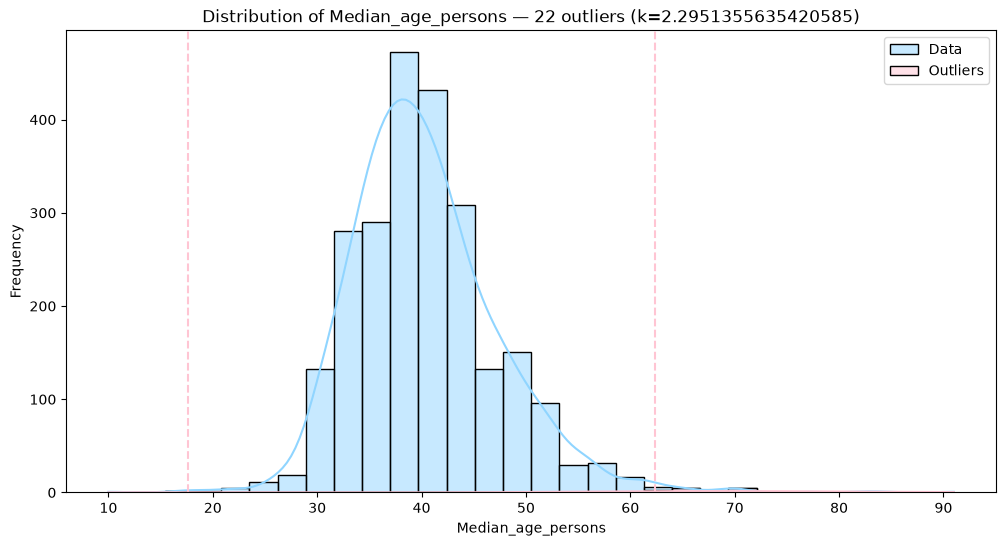

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


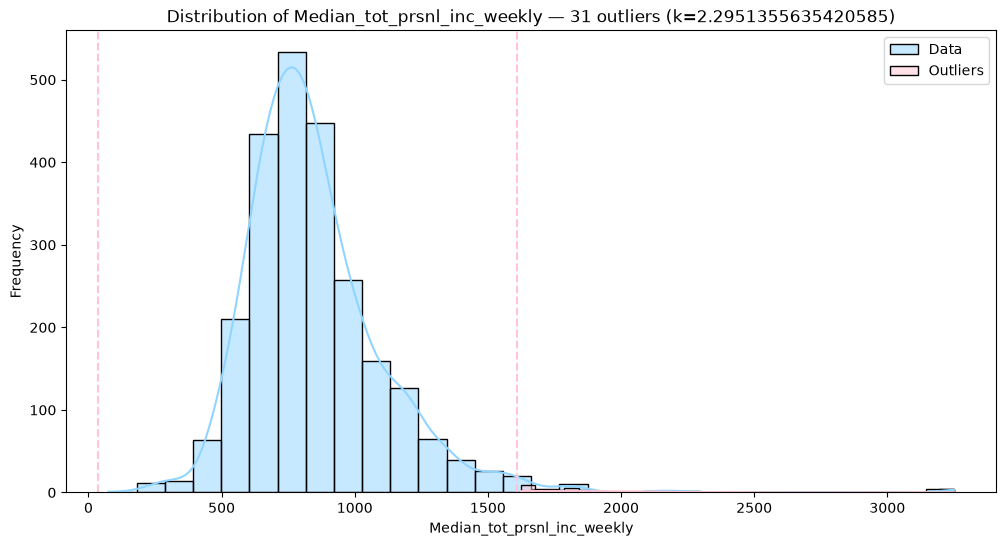

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


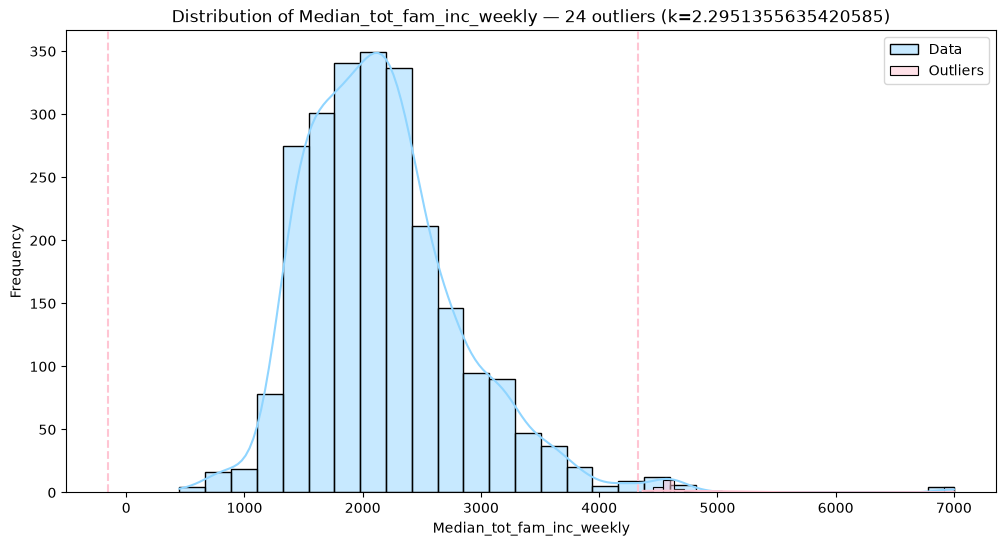

In [11]:
# Helper functions to identify and visualise outliers using the IQR method (threshold = 3)
import math 
threshold = math.sqrt(math.log(2472)) - 0.5

def iqr_bounds(df, col, k=3.0):
    q1, q3 = df.approxQuantile(col, [0.25, 0.75], 0.0)   # distributed quantiles
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def plot_distribution_with_outliers(df, col, k=3.0):
    lo, hi = iqr_bounds(df, col, k)
    pdf = df.select(col).dropna().toPandas()             # small (~2.5k rows) -> safe to collect
    out = pdf[(pdf[col] < lo) | (pdf[col] > hi)]
    plt.figure(figsize=(12, 6))
    sns.histplot(pdf[col], bins=30, kde=True, color="#90D5FF", label="Data")
    if len(out):
        sns.histplot(out[col], bins=30, kde=True, color="#FFC5D3", label="Outliers")
    plt.axvline(lo, color="#FFC5D3", ls="--"); plt.axvline(hi, color="#FFC5D3", ls="--")
    plt.title(f"Distribution of {col} — {len(out)} outliers (k={k})")
    plt.xlabel(col); plt.ylabel("Frequency"); plt.legend()
    plt.show()

relevant_cols = ["Median_age_persons", "Median_tot_prsnl_inc_weekly", "Median_tot_fam_inc_weekly"]
for col in relevant_cols:
    plot_distribution_with_outliers(sa2, col, k=threshold)


Data is mostly normally distributed with sight right-skew. 

Correlation between Median Age and Median Personal Income: 0.060
Correlation between Median Age and Median Family Income:   0.034


/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


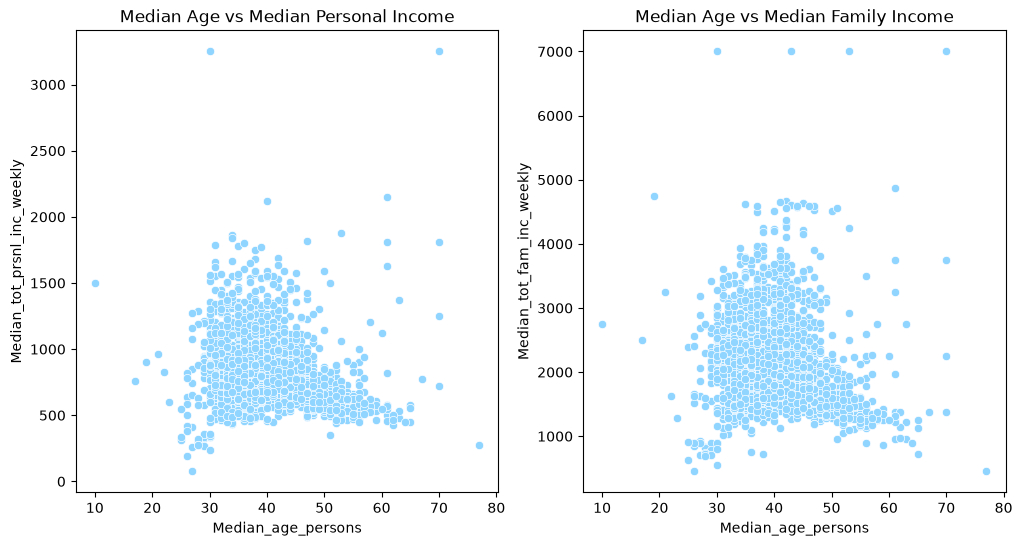

In [12]:
#Correlation between age and household income, and age and family income. 
corr_personal = sa2.stat.corr("Median_age_persons", "Median_tot_prsnl_inc_weekly")
corr_family   = sa2.stat.corr("Median_age_persons", "Median_tot_fam_inc_weekly")
print(f"Correlation between Median Age and Median Personal Income: {corr_personal:.3f}")
print(f"Correlation between Median Age and Median Family Income:   {corr_family:.3f}")

# collect only the small columns needed for the scatter plots 
pdf = sa2.select("Median_age_persons",
                 "Median_tot_prsnl_inc_weekly",
                 "Median_tot_fam_inc_weekly").dropna().toPandas()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(data=pdf, x="Median_age_persons", y="Median_tot_prsnl_inc_weekly", color="#90D5FF")
plt.title("Median Age vs Median Personal Income")
plt.subplot(1, 2, 2)
sns.scatterplot(data=pdf, x="Median_age_persons", y="Median_tot_fam_inc_weekly", color="#90D5FF")
plt.title("Median Age vs Median Family Income")
plt.show()

straight line at top --> maybe a cap or a max on ABS counting (bottom of top range?), a few outliers, but useful indicators.


# Crosswalk 

connect SA2 codes to postcodes w/ pop weighting. can be updated later, but servicable for right now

In [14]:
# Crosswalk w/ spatial overlay: POA (postcode) to SA2 (statistical area 2) 
import geopandas as gpd

EQUAL_AREA = 3577   # projects to meters for accurate area calculations

# read boundaries of ABS + POA
poa = gpd.read_file("../data/landing/POA_2021_AUST_GDA2020.shp")[["POA_CODE21", "geometry"]].to_crs(EQUAL_AREA)
sa2_shape = gpd.read_file("../data/landing/SA2_2021_AUST_GDA2020.shp")[["SA2_CODE21", "geometry"]].to_crs(EQUAL_AREA)

#smooth out any invalid boundaries
poa["geometry"] = poa.geometry.buffer(0)
sa2_shape["geometry"] = sa2_shape.geometry.buffer(0)


#ratio of each POA's area that falls in each SA2 (must sum to 1 per POA)
inter = gpd.overlay(poa, sa2_shape, how="intersection", keep_geom_type=True)
inter["piece_area"] = inter.geometry.area
inter["RATIO"] = inter["piece_area"] / inter.groupby("POA_CODE21")["piece_area"].transform("sum")

#crosswalk
xwalk = (inter[["POA_CODE21", "SA2_CODE21", "RATIO"]]
         .rename(columns={"POA_CODE21": "POA_CODE_2021", "SA2_CODE21": "SA2_CODE_2021"}))

#final postcode column (POA = Postcode)
xwalk["postcode"] = xwalk["POA_CODE_2021"]

#back to spark to add to curated data
corr = spark.createDataFrame(xwalk)
corr.write.mode("overwrite").parquet("../data/curated/sa2_poa_crosswalk")
corr.orderBy("POA_CODE_2021", "SA2_CODE_2021").show(10)

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


+-------------+-------------+--------------------+--------+
|POA_CODE_2021|SA2_CODE_2021|               RATIO|postcode|
+-------------+-------------+--------------------+--------+
|         0800|    701011002|  0.9999999912377574|    0800|
|         0800|    701011004|3.057537884491462E-9|    0800|
|         0800|    701011005|5.587875970102027E-9|    0800|
|         0800|    701011008|1.168287041455633...|    0800|
|         0810|    701011001|5.272689984496172...|    0810|
|         0810|    701021010| 0.05075941550264613|    0810|
|         0810|    701021011|9.079431185448995...|    0810|
|         0810|    701021013| 0.10994666334812009|    0810|
|         0810|    701021014|1.049806828054243...|    0810|
|         0810|    701021016|0.058301515635702475|    0810|
+-------------+-------------+--------------------+--------+
only showing top 10 rows


In [15]:
# merge the crosswalk with the SA2 medians and proportions to get a postcode-level dataset

from pyspark.sql import functions as F
from pyspark.sql.window import Window

window = Window.partitionBy("SA2_CODE_2021").orderBy(F.desc("RATIO"))

#postcode for each SA2 is the one with the largest area ratio (RATIO)
sa2_postcode = (
    corr
    .withColumn("rn", F.row_number().over(window))
    .filter(F.col("rn") == 1)
    .select("SA2_CODE_2021", "postcode")
)

#add postcode to the sa2 dataset
sa2_postcode_level = sa2.join(
    sa2_postcode,
    on="SA2_CODE_2021",
    how="left"
)

sa2_postcode_level.show()
sa2_postcode_level.write.mode("overwrite").parquet("data/curated/sa2_postcode_level.parquet")

+-------------+------------------+-----------------------------+---------------------------+------------------+-------------------------+----------------------------+-------------------------+----------------------+----------+--------+
|SA2_CODE_2021|Median_age_persons|Median_mortgage_repay_monthly|Median_tot_prsnl_inc_weekly|Median_rent_weekly|Median_tot_fam_inc_weekly|Average_num_psns_per_bedroom|Median_tot_hhd_inc_weekly|Average_household_size|prop_18_34|postcode|
+-------------+------------------+-----------------------------+---------------------------+------------------+-------------------------+----------------------------+-------------------------+----------------------+----------+--------+
|    101021008|              38.0|                       1950.0|                      975.0|             350.0|                   2334.0|                         0.8|                   1989.0|                   2.6|    0.2317|    2620|
|    101021610|              31.0|                      

In [16]:
sa2_postcode_level.printSchema()

root
 |-- SA2_CODE_2021: string (nullable = true)
 |-- Median_age_persons: double (nullable = true)
 |-- Median_mortgage_repay_monthly: double (nullable = true)
 |-- Median_tot_prsnl_inc_weekly: double (nullable = true)
 |-- Median_rent_weekly: double (nullable = true)
 |-- Median_tot_fam_inc_weekly: double (nullable = true)
 |-- Average_num_psns_per_bedroom: double (nullable = true)
 |-- Median_tot_hhd_inc_weekly: double (nullable = true)
 |-- Average_household_size: double (nullable = true)
 |-- prop_18_34: double (nullable = true)
 |-- postcode: string (nullable = true)



Hey guys, I have left all of the variables in as I didn't want to make that dec without consulting as you guys might have different ideas about whats relevant. I think median age, personal/family income and maybe rent are important along with prop_18_34 and postcode, but the others can be dropped if you agree. 